# Market model — data, calibration, validation, simulation

Companion to **`model.md`** (the written reference). This notebook loads the empirical
fundamental, shows the locked calibration, validates the simulated stylised facts against
the real ES tape, and runs a sample cleared session. Run top-to-bottom from the repo root.

In [7]:
import numpy as np, pandas as pd, json
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 3.4), 'axes.grid': True, 'grid.alpha': 0.3})

from model.globals import ModelParams, CALIBRATED, day_start_steps
from model.simulation import Simulation
from model.run_simulation import build_traders, build_clearing_tier

REGIME = 'stressed'   # 'calm' or 'stressed'

def hill(x, k_frac=0.05):
    """Hill (1975) tail index on |x|; smaller = fatter tails (equity ~3)."""
    x = np.sort(np.abs(np.asarray(x)))[::-1]
    k = max(10, int(k_frac * len(x)))
    xk = x[:k]
    return 1.0 / np.mean(np.log(xk[:-1] / xk[-1]))

def acf(x, lags):
    x = np.asarray(x) - np.mean(x); v = np.dot(x, x)
    return [float(np.dot(x[:-l], x[l:]) / v) for l in lags]

def intraday_logret(mid, regime):
    """1-min log returns with the overnight session-boundary returns excluded."""
    m = np.asarray(mid, float); r = np.diff(np.log(m))
    drop = {s - 1 for s in day_start_steps(regime) if s > 0}
    return r[[i for i in range(len(r)) if i not in drop]]

## 1. Data — the fundamental and the empirical stylised facts

`V_t` is the Kalman-filtered real ES efficient price with overnight gaps retained, so its
intraday returns are the empirical calibration targets.

stressed: 11,445 1-min bars over 29 sessions, maxDD -33.0%


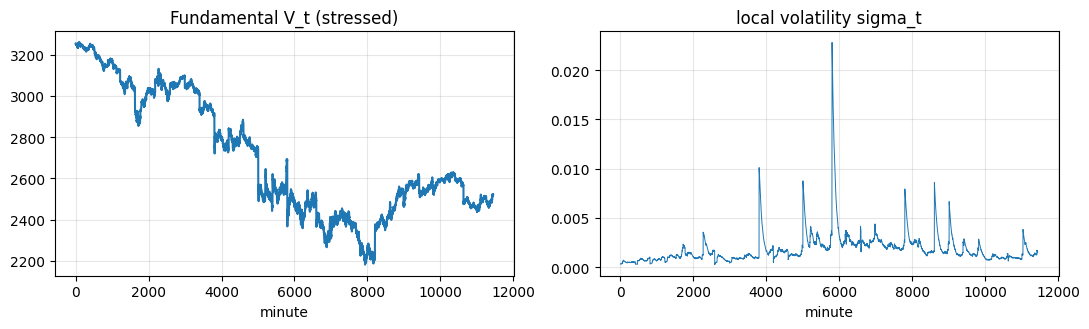

In [8]:
fv = pd.read_csv(f'data/fv_{REGIME}.csv')
dd = 100 * (fv.V_smooth.min() / fv.V_smooth.iloc[0] - 1)
print(f'{REGIME}: {len(fv):,} 1-min bars over {len(day_start_steps(REGIME))} sessions, maxDD {dd:.1f}%')
fig, ax = plt.subplots(1, 2)
ax[0].plot(fv.V_smooth.values); ax[0].set_title(f'Fundamental V_t ({REGIME})'); ax[0].set_xlabel('minute')
ax[1].plot(fv.sigma_t.values, lw=0.7); ax[1].set_title('local volatility sigma_t'); ax[1].set_xlabel('minute')
plt.tight_layout(); plt.show()

empirical intraday returns: std=1.82e-03  Hill=3.25  excess kurtosis=35


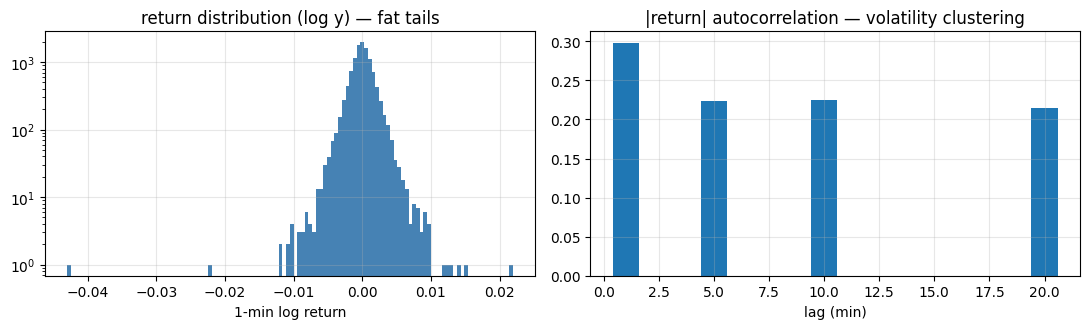

In [9]:
emp = intraday_logret(fv.V_smooth.values, REGIME)
lags = [1, 5, 10, 20]
print(f'empirical intraday returns: std={emp.std():.2e}  Hill={hill(emp):.2f}  excess kurtosis={pd.Series(emp).kurt():.0f}')
fig, ax = plt.subplots(1, 2)
ax[0].hist(emp, bins=120, log=True, color='steelblue')
ax[0].set_title('return distribution (log y) — fat tails'); ax[0].set_xlabel('1-min log return')
ax[1].bar(lags, acf(np.abs(emp), lags), width=1.2)
ax[1].set_title('|return| autocorrelation — volatility clustering'); ax[1].set_xlabel('lag (min)')
plt.tight_layout(); plt.show()

## 2. Calibration — the locked optimum

Behavioural theta is the grid optimum (`output/relock/`), wired into `globals.CALIBRATED`.
Method and validation are in `model.md` section 5.

calm     : ft_sigma_c=0.95, zi_alpha=0.26, zi_mu=0.0125, zi_delta=0.02
stressed : ft_sigma_c=0.25, zi_alpha=0.32, zi_mu=0.05833, zi_delta=0.02, p_zi=0.18

stressed grid optimum  D=5.76   components KS 2.67, V 0.47, ACF1 0.34, ACF2 1.45, Hill 0.82


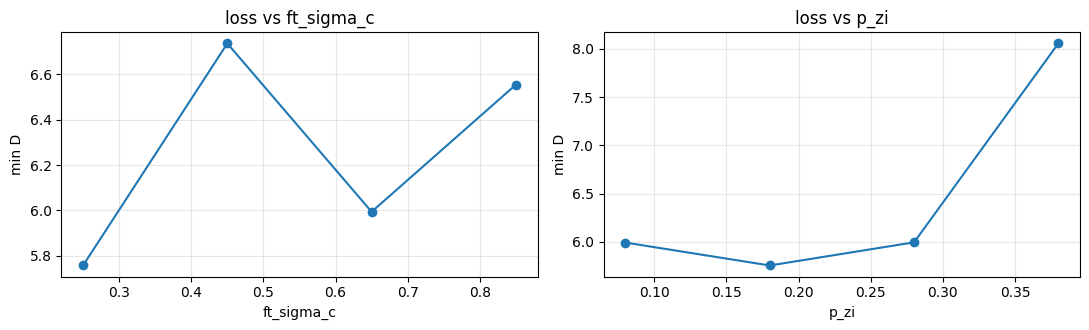

In [10]:
for reg in ('calm', 'stressed'):
    print(f'{reg:9s}: ' + ', '.join(f'{k}={v}' for k, v in CALIBRATED[reg].items()))
g = json.load(open('output/relock/grid_stressed.json'))['results']['stressed']
print(f'\nstressed grid optimum  D={g["D_grid"]:.2f}   components ' +
      ', '.join(f'{k} {v:.2f}' for k, v in g['component_deltas'].items()))
gs = pd.read_csv('output/relock/grid_surface_stressed.csv')
fig, ax = plt.subplots(1, 2)
for col, a in zip(['ft_sigma_c', 'p_zi'], ax):
    m = gs.groupby(col)['D'].min()
    a.plot(m.index, m.values, 'o-'); a.set_xlabel(col); a.set_ylabel('min D'); a.set_title(f'loss vs {col}')
plt.tight_layout(); plt.show()

## 3. Validation — simulated vs empirical

Run the model at the locked theta and compare the stylised facts to the empirical tape.

                  std    Hill
empirical    1.82e-03    3.25
simulated    1.16e-03    3.24


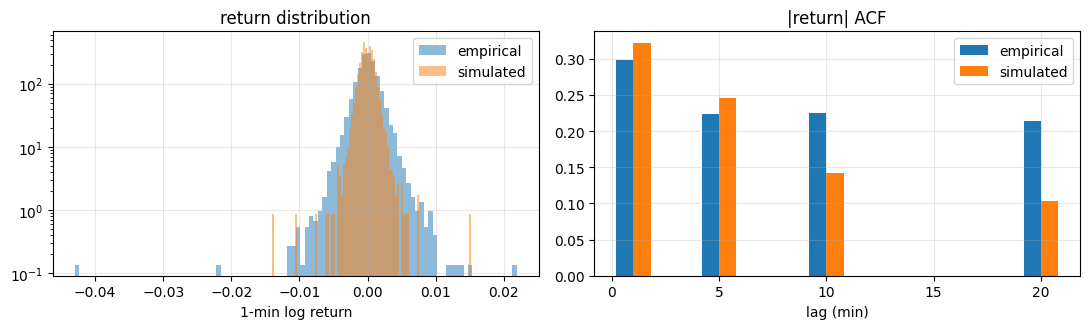

In [11]:
def sim_returns(regime, seed=11, n=4000):
    p = ModelParams(n_fundamental=40, n_momentum=20, n_zi=40,
                    v0=float(pd.read_csv(f'data/fv_{regime}.csv').V_smooth[0]),
                    tick_size=0.25, dt_minutes=1.0, **CALIBRATED[regime], stressed=(regime == 'stressed'))
    s = Simulation(p, build_traders(p, seed=seed), seed=seed); s.run(n)
    mid = np.array([m for m in s.history['mid_price'] if m == m])
    return intraday_logret(mid, regime)

sim = sim_returns(REGIME, n=4000)
print(f'{"":11s}{"std":>10}{"Hill":>8}')
print(f'{"empirical":11s}{emp.std():>10.2e}{hill(emp):>8.2f}')
print(f'{"simulated":11s}{sim.std():>10.2e}{hill(sim):>8.2f}')
fig, ax = plt.subplots(1, 2)
ax[0].hist(emp, bins=100, log=True, alpha=0.5, density=True, label='empirical')
ax[0].hist(sim, bins=100, log=True, alpha=0.5, density=True, label='simulated')
ax[0].set_title('return distribution'); ax[0].legend(); ax[0].set_xlabel('1-min log return')
w = 0.4
ax[1].bar([l - w for l in lags], acf(np.abs(emp), lags), width=2 * w, label='empirical')
ax[1].bar([l + w for l in lags], acf(np.abs(sim), lags), width=2 * w, label='simulated')
ax[1].set_title('|return| ACF'); ax[1].legend(); ax[1].set_xlabel('lag (min)')
plt.tight_layout(); plt.show()

## 4. Simulation — a sample cleared session

One stressed session with the full clearing tier: price tracks the fundamental, and the
margin / default machinery runs on top.

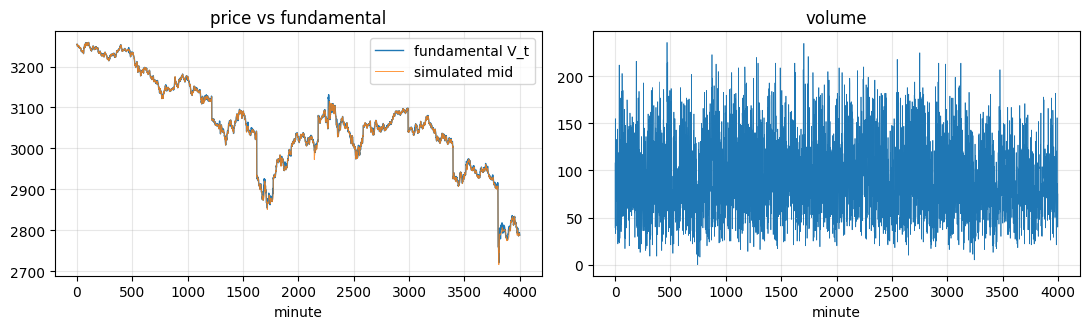

clearing tier: default fund $1.52B, 0 client defaults, deepest waterfall L0


In [12]:
p = ModelParams(n_fundamental=30, n_momentum=20, n_zi=40, n_bcm=10, n_nbcm=5, n_bcm_with_clients=5,
                v0=float(fv.V_smooth[0]), tick_size=0.25, dt_minutes=1.0, **CALIBRATED['stressed'], stressed=True)
tr = build_traders(p, seed=3); ccp = build_clearing_tier(tr, p, seed=3)
s = Simulation(p, tr, seed=3, ccp=ccp); s.run(4000)
mid = np.array(s.history['mid_price']); fund = np.array(s.history['fundamental'])
fig, ax = plt.subplots(1, 2)
ax[0].plot(fund, label='fundamental V_t', lw=1.0)
ax[0].plot(mid, label='simulated mid', lw=0.7, alpha=0.8)
ax[0].set_title('price vs fundamental'); ax[0].legend(); ax[0].set_xlabel('minute')
ax[1].plot(s.history['volume'], lw=0.5); ax[1].set_title('volume'); ax[1].set_xlabel('minute')
plt.tight_layout(); plt.show()
ch = pd.DataFrame(s.clearing_history); cl = pd.DataFrame(s.client_history)
print(f'clearing tier: default fund ${ccp.total_df/1e9:.2f}B, {len(cl)} client defaults, '
      f'deepest waterfall L{int(ch.waterfall_level.max()) if len(ch) else 0}')